In [22]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

Pobranie najbliższych sąsiadów

In [2]:
def get_direct_neighbors(grid, x, y):
    neighbors = []
    grid_size = grid.shape[0]
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < grid_size and 0 <= ny < grid_size:
            neighbors.append(grid[nx, ny])
    return neighbors

Sprawdzenie czy agent jest usatysfakcjonowany

In [3]:
def is_satisfied(grid, x, y, tolerance):
    agent = grid[x, y]
    if agent == 0:
        return True

    neighbors = get_direct_neighbors(grid, x, y)
    if not neighbors:
        return False

    same_type = sum(1 for n in neighbors if n == agent)
    return same_type / len(neighbors) >= tolerance

Inicjalizacja Siatki

In [4]:
def initialize_grid(grid_size=50, density=0.75):
    num_cells = grid_size**2
    num_agents = int(num_cells * density)
    num_agents = (num_agents // 2) * 2  # Niech liszba agentów będzie parzysta

    # Podzielenie agentów
    agents = np.zeros(num_cells, dtype=np.int8)
    agents[:num_agents//2] = 1
    agents[num_agents//2:num_agents] = 2

    # Rozrzucenie agentów
    np.random.shuffle(agents)
    grid = agents.reshape(grid_size, grid_size)

    # Ustawienie pustych miejsc
    empty_spots = set((x, y) for x in range(grid_size) for y in range(grid_size) if grid[x, y] == 0)

    return grid, empty_spots

Pobranie losowego Agenta

In [5]:
def getRandomAgent(grid, unhappy_agents):
    if not unhappy_agents:
        return None
    return list(unhappy_agents)[np.random.randint(0, len(unhappy_agents))]

Jeden krok

In [6]:
def step(agent, grid, tolerance, empty_spots, unhappy_agents):
    if agent is None:
        return grid, empty_spots, unhappy_agents, False

    x, y = agent
    grid_size = grid.shape[0]

    # Usunięcie agenta z listy smutnych jeśli teraz zadowolony
    if is_satisfied(grid, x, y, tolerance) or grid[x, y] == 0:
        unhappy_agents.remove(agent)
        return grid, empty_spots, unhappy_agents, False

    if empty_spots:
        # Losowy punkt z pustych
        new_x, new_y = list(empty_spots)[np.random.randint(0, len(empty_spots))]

        # Ruszenie agenta
        agent_type = grid[x, y]
        grid[new_x, new_y] = agent_type
        grid[x, y] = 0

        # Aktualizacja pustych miejsc
        empty_spots.remove((new_x, new_y))
        empty_spots.add((x, y))

        # wywalenie z listy smutnych
        unhappy_agents.remove((x, y))

        # Sprawdzenie czy jest szczęśliwy w nowym miejscu
        if not is_satisfied(grid, new_x, new_y, tolerance):
            unhappy_agents.add((new_x, new_y))

        # Sprawdzenie przeszłych sąsiadów
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and
                    grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    unhappy_agents.discard((nx, ny))
                else:
                    unhappy_agents.add((nx, ny))

        # Sprawdzenie nowych sąsiadów
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = new_x + dx, new_y + dy
            if (0 <= nx < grid_size and 0 <= ny < grid_size and
                    grid[nx, ny] != 0):
                if is_satisfied(grid, nx, ny, tolerance):
                    unhappy_agents.discard((nx, ny))
                else:
                    unhappy_agents.add((nx, ny))

        return grid, empty_spots, unhappy_agents, True

    return grid, empty_spots, unhappy_agents, False

Rysowanie siatki

In [7]:
def plot_grid(grid, iteration, cmap):
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    plt.title(f'Iteration: {iteration}')
    plt.show(block=False)
    plt.pause(0.1)
    print(f"Created plot for iteration {iteration}")

Symulacja

In [8]:
def run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.3, max_iterations=10000, plot=True):
    # Inicjalizacja
    grid, empty_spots = initialize_grid(grid_size, density)

    # Ustawienie kolorów
    cmap = plt.cm.colors.ListedColormap(['white', 'green', 'blue'])

    # Trzymanie smutnych agentów
    unhappy_agents = set()
    for x in range(grid_size):
        for y in range(grid_size):
            if grid[x, y] != 0 and not is_satisfied(grid, x, y, tolerance):
                unhappy_agents.add((x, y))

    # Rysunek 0 iteracji
    if plot:
        plot_grid(grid, 0, cmap)

    iteration = 0

    unhappy_agents_history = []

    # Pętla symulacyjna
    while iteration < max_iterations:
        # Pobranie losowego smutnego agenta
        agent = getRandomAgent(grid, unhappy_agents)

        if agent is None:
            break

        # Krok symulacyjny
        grid, empty_spots, unhappy_agents, has_moved = step(agent, grid, tolerance, empty_spots, unhappy_agents)

        # Zwiększenie iteracji tylko jak wykonano ruch
        if has_moved:
            iteration += 1

            # Rysunek 1000 iteracji
            if iteration == 1000:
                if plot:
                    plot_grid(grid, 1000, cmap)
        unhappy_agents_history.append(len(list(unhappy_agents)))

    if plot:
        # Info o  ostatniej iteracji
        if iteration >= max_iterations:
            print(f"Reached maximum iteration limit: {max_iterations}")
        elif not unhappy_agents:
            print(f"All agents are satisfied - equilibrium reached at iteration {iteration}")

    if plot:
        # Rysunek ostatniej iteracji
        if iteration != 1000:
            plot_grid(grid, iteration, cmap)

        plt.show()

    return unhappy_agents_history, grid

Wstępne symulacje i wnioski:

Dla 75%:
Punkt krytyczny: Tolerancja 26%

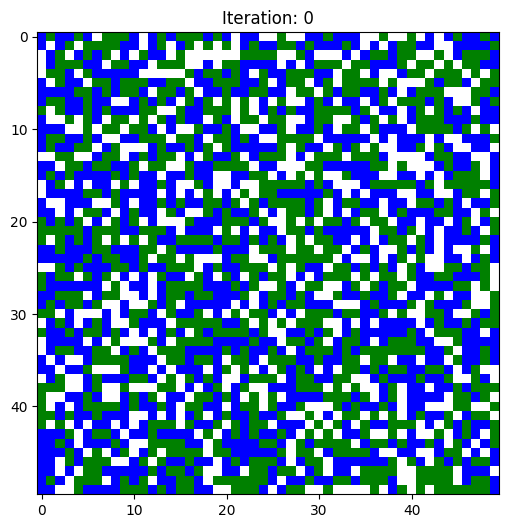

Created plot for iteration 0
All agents are satisfied - equilibrium reached at iteration 316


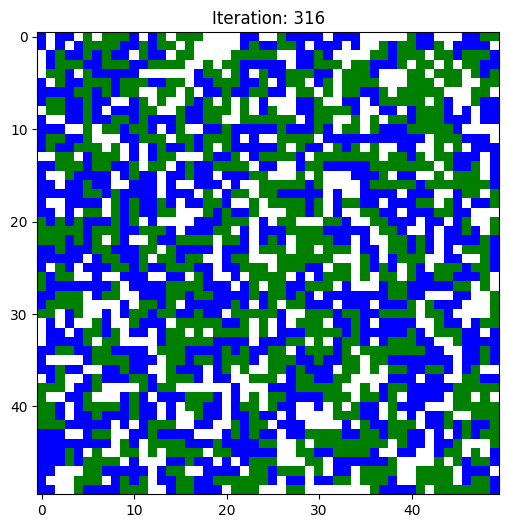

Created plot for iteration 316


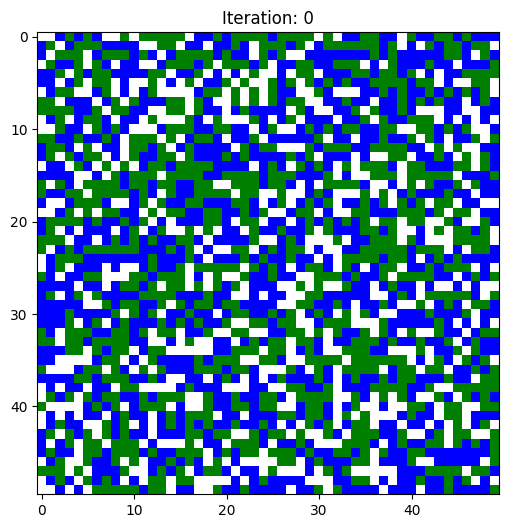

Created plot for iteration 0


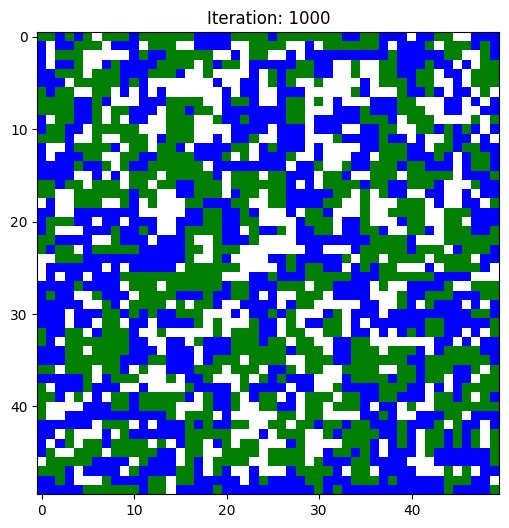

Created plot for iteration 1000
All agents are satisfied - equilibrium reached at iteration 2221


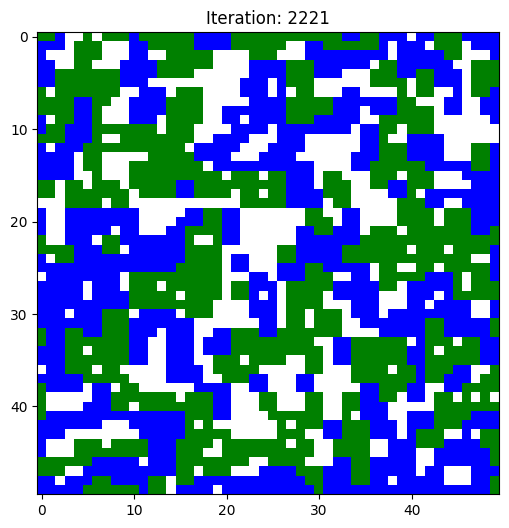

Created plot for iteration 2221


([931,
  928,
  929,
  929,
  927,
  928,
  928,
  927,
  926,
  927,
  927,
  926,
  925,
  925,
  925,
  926,
  925,
  925,
  924,
  923,
  921,
  919,
  918,
  918,
  918,
  917,
  917,
  918,
  917,
  917,
  918,
  916,
  916,
  915,
  913,
  912,
  911,
  911,
  912,
  912,
  912,
  909,
  910,
  910,
  911,
  908,
  909,
  909,
  907,
  903,
  901,
  901,
  901,
  902,
  901,
  900,
  901,
  900,
  899,
  899,
  897,
  897,
  895,
  894,
  895,
  894,
  892,
  892,
  891,
  892,
  891,
  889,
  886,
  887,
  888,
  888,
  888,
  886,
  886,
  886,
  886,
  884,
  882,
  881,
  882,
  879,
  876,
  873,
  871,
  869,
  868,
  866,
  864,
  863,
  863,
  861,
  860,
  861,
  860,
  859,
  860,
  859,
  859,
  859,
  859,
  859,
  859,
  857,
  857,
  855,
  854,
  853,
  852,
  848,
  848,
  846,
  845,
  846,
  845,
  845,
  844,
  844,
  843,
  841,
  840,
  839,
  839,
  839,
  837,
  836,
  833,
  833,
  833,
  834,
  831,
  831,
  830,
  827,
  827,
  826,
  826,
  826,
  824,

In [9]:
run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.25, max_iterations=10000, plot=True)
run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.26, max_iterations=10000, plot=True)

Dla 85%:
Punkt krytyczny: Tolerancja 26%

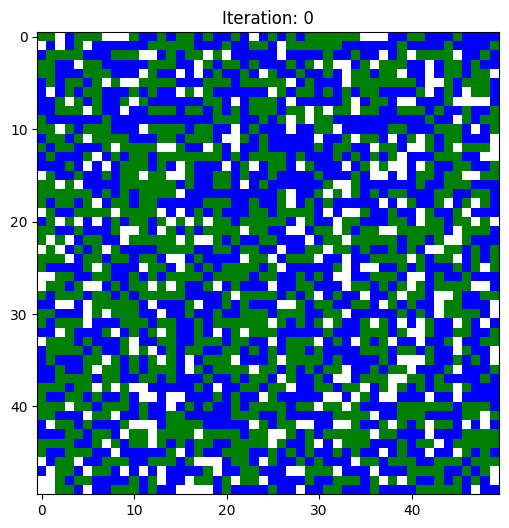

Created plot for iteration 0
All agents are satisfied - equilibrium reached at iteration 236


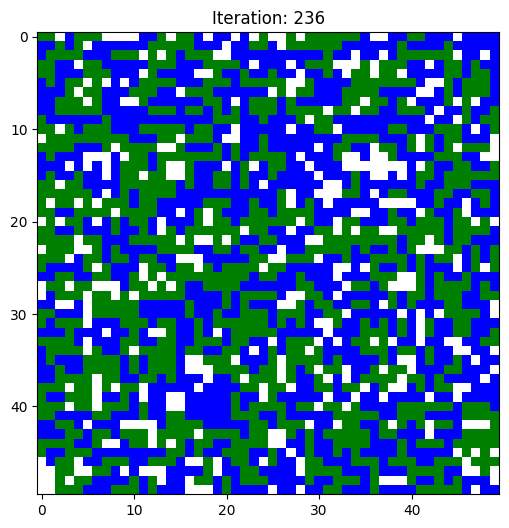

Created plot for iteration 236


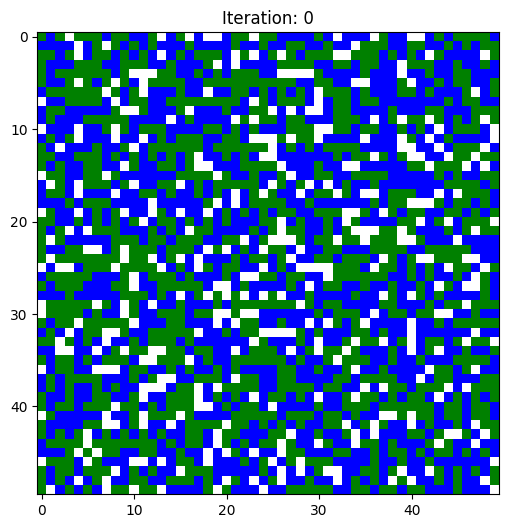

Created plot for iteration 0


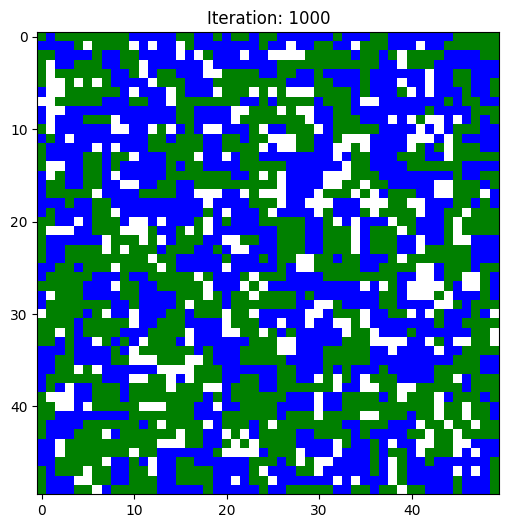

Created plot for iteration 1000
All agents are satisfied - equilibrium reached at iteration 1608


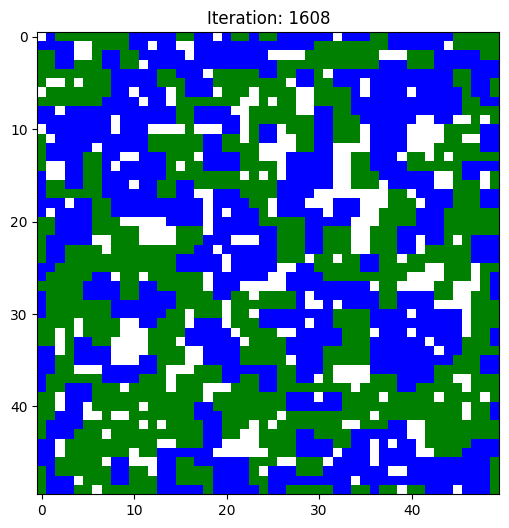

Created plot for iteration 1608


([879,
  879,
  876,
  876,
  876,
  872,
  872,
  870,
  869,
  870,
  867,
  866,
  864,
  863,
  864,
  862,
  860,
  858,
  855,
  855,
  854,
  854,
  854,
  853,
  853,
  852,
  850,
  847,
  845,
  846,
  844,
  843,
  843,
  840,
  840,
  840,
  840,
  840,
  839,
  840,
  840,
  840,
  840,
  840,
  839,
  839,
  839,
  837,
  836,
  836,
  836,
  834,
  832,
  831,
  828,
  827,
  825,
  825,
  825,
  825,
  824,
  821,
  820,
  820,
  818,
  817,
  816,
  814,
  813,
  812,
  810,
  809,
  807,
  806,
  804,
  804,
  803,
  802,
  803,
  802,
  800,
  800,
  799,
  797,
  796,
  794,
  793,
  792,
  791,
  791,
  790,
  787,
  786,
  785,
  785,
  784,
  783,
  780,
  780,
  780,
  781,
  782,
  782,
  779,
  779,
  777,
  777,
  777,
  773,
  772,
  770,
  768,
  768,
  768,
  767,
  766,
  764,
  762,
  759,
  759,
  758,
  756,
  756,
  755,
  753,
  751,
  750,
  749,
  749,
  748,
  746,
  743,
  741,
  742,
  740,
  740,
  741,
  739,
  738,
  736,
  734,
  733,
  733,

In [10]:
run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.25, max_iterations=10000, plot=True)
run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.26, max_iterations=10000, plot=True)

Dla 95%:
Punkt krytyczny: Tolerancja 26%

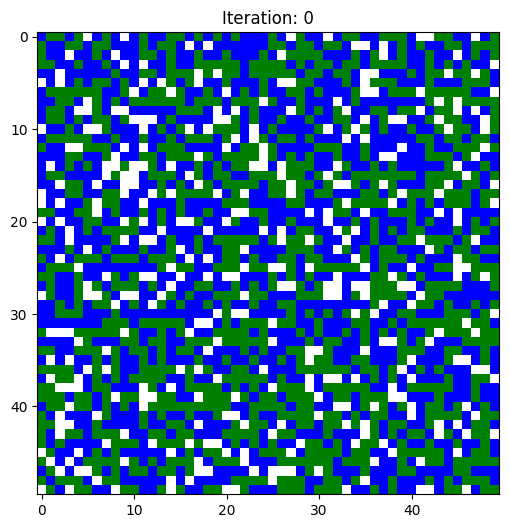

Created plot for iteration 0
All agents are satisfied - equilibrium reached at iteration 249


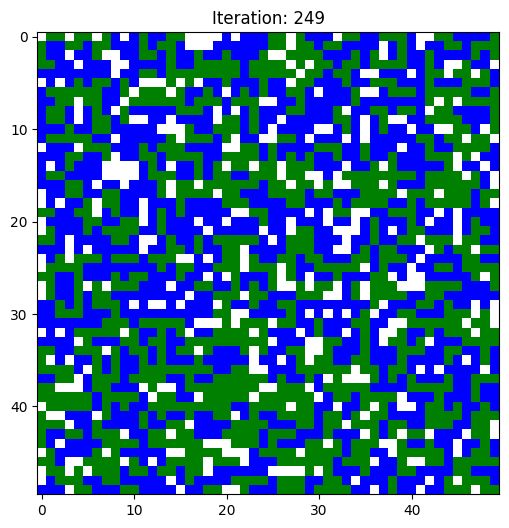

Created plot for iteration 249


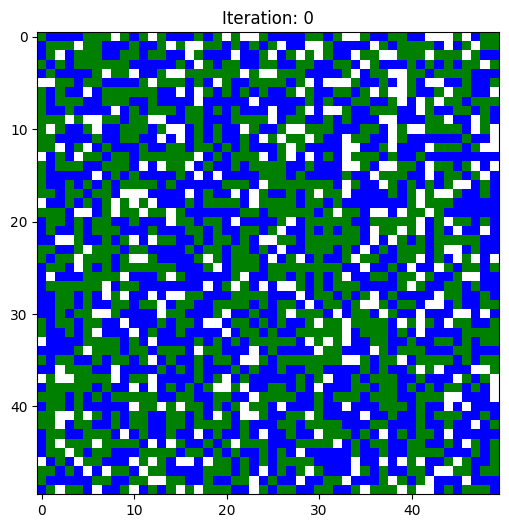

Created plot for iteration 0


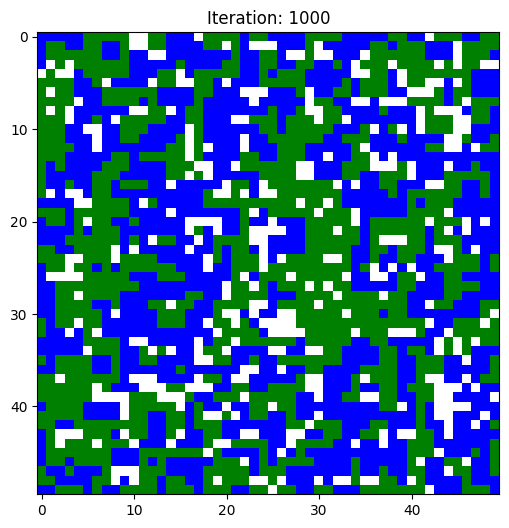

Created plot for iteration 1000
All agents are satisfied - equilibrium reached at iteration 1636


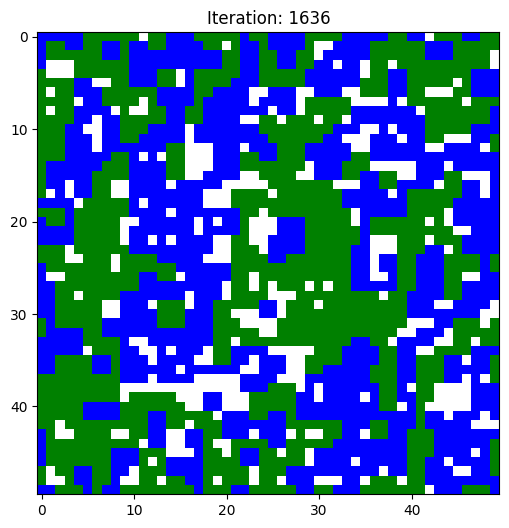

Created plot for iteration 1636


([879,
  879,
  880,
  880,
  878,
  875,
  875,
  872,
  871,
  872,
  870,
  869,
  868,
  866,
  864,
  864,
  865,
  865,
  865,
  864,
  864,
  863,
  862,
  862,
  862,
  862,
  862,
  860,
  857,
  857,
  854,
  852,
  851,
  850,
  848,
  847,
  846,
  846,
  843,
  842,
  841,
  842,
  841,
  839,
  837,
  836,
  837,
  835,
  833,
  831,
  831,
  830,
  829,
  826,
  824,
  824,
  824,
  821,
  819,
  820,
  819,
  819,
  820,
  818,
  818,
  816,
  814,
  813,
  811,
  810,
  808,
  807,
  807,
  807,
  808,
  807,
  808,
  809,
  809,
  809,
  807,
  806,
  803,
  804,
  803,
  802,
  803,
  803,
  803,
  801,
  802,
  800,
  799,
  797,
  795,
  793,
  792,
  790,
  787,
  787,
  786,
  786,
  783,
  782,
  781,
  778,
  777,
  777,
  777,
  775,
  775,
  776,
  777,
  775,
  775,
  773,
  773,
  773,
  772,
  770,
  768,
  768,
  767,
  768,
  766,
  766,
  763,
  762,
  760,
  759,
  759,
  757,
  757,
  754,
  752,
  751,
  752,
  751,
  749,
  747,
  746,
  744,
  743,

In [11]:
run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.25, max_iterations=10000, plot=True)
run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.26, max_iterations=10000, plot=True)

Dalsza część zadania

In [12]:
data75, grid75 = run_schelling_simulation(grid_size=50, density=0.75, tolerance=0.3, plot=False)
data85, grid85 = run_schelling_simulation(grid_size=50, density=0.85, tolerance=0.3, plot=False)
data95, grid95 = run_schelling_simulation(grid_size=50, density=0.95, tolerance=0.3, plot=False)

Wykresy liczby nieszczęśliwych agentów w zależności od tolerancji

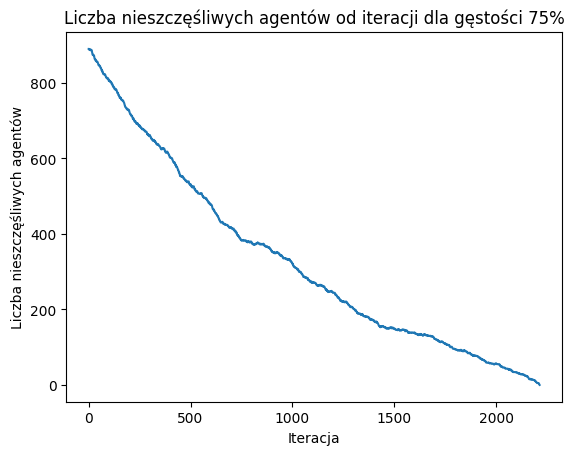

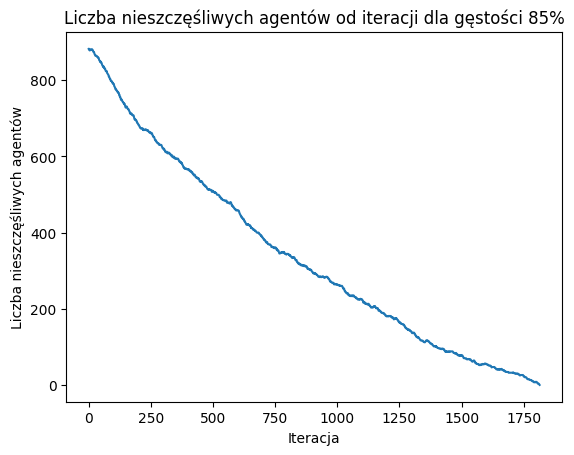

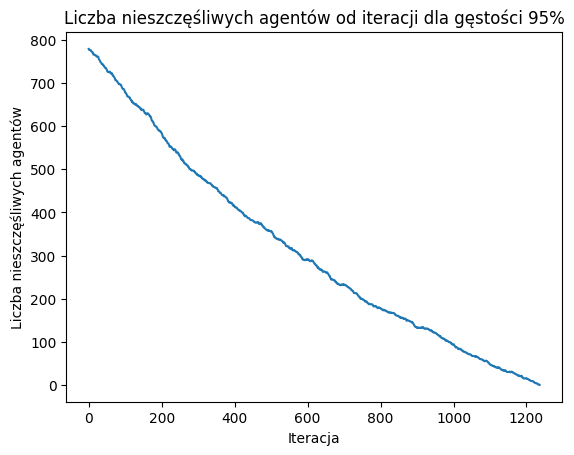

In [14]:
plt.plot(data75)
plt.xlabel('Iteracja')
plt.ylabel('Liczba nieszczęśliwych agentów')
plt.title('Liczba nieszczęśliwych agentów od iteracji dla gęstości 75%')
plt.show()

plt.plot(data85)
plt.xlabel('Iteracja')
plt.ylabel('Liczba nieszczęśliwych agentów')
plt.title('Liczba nieszczęśliwych agentów od iteracji dla gęstości 85%')
plt.show()

plt.plot(data95)
plt.xlabel('Iteracja')
plt.ylabel('Liczba nieszczęśliwych agentów')
plt.title('Liczba nieszczęśliwych agentów od iteracji dla gęstości 95%')
plt.show()

Wykres tolerancji - Oblicza/Tworzy wykres dla symulacji puszczonej jeden raz na krok tolerancji (UWAGA: długo mieli 1m 17s)

In [15]:
def wykres_tolerancji(step, density, grid_size=20):
    unsatf_list = []
    xi = []
    for i in range(1, int(1/step + 1)):
        #tutaj biore for'a od 1 bo tolerancja dla 0 to jakies dziwne rzeczy wychodza, do sprawdzenia czemu tak
        unsatf_agents, grid = run_schelling_simulation(grid_size=grid_size, density=density, tolerance=i*step, plot=False)
        unsatf_list.append(unsatf_agents[-1])
        xi.append(i*step)

    return unsatf_list, xi

In [16]:
wykres_tolerancji(0.01, 0.75, grid_size=40)
wykres_tolerancji(0.01, 0.85, grid_size=40)
wykres_tolerancji(0.01, 0.95, grid_size=40)

([0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  149,
  130,
  135,
  145,
  158,
  122,
  158,
  167,
  138,
  131,
  117,
  147,
  154,
  148,
  123,
  115,
  224,
  246,
  263,
  221,
  258,
  253,
  271,
  237,
  237,
  1382,
  1372,
  1387,
  1382,
  1384,
  1371,
  1384,
  1379,
  1377,
  1379,
  1380,
  1388,
  1377,
  1378,
  1389,
  1403,
  1386,
  1375,
  1385,
  1389,
  1362,
  1357,
  1376,
  1351,
  1385],
 [0.01,
  0.02,
  0.03,
  0.04,
  0.05,
  0.06,
  0.07,
  0.08,
  0.09,
  0.1,
  0.11,
  0.12,
  0.13,
  0.14,
  0.15,
  0.16,
  0.17,
  0.18,
  0.19,
  0.2,
  0.21,
  0.22,
  0.23,
  0.24,
  0.25,
  0.26,
  0.27,
  0.28,
  0.29,
  0.3,
  0.31,
  0.32,
  0.33,
  0.34,
  0.35000000000000003,
  0.36,
  0.37,
  0.38,
  0.39,
  0.4,
  0.41000000000000003,
  0.42,
  0.43,
  0.

Średnia tolerancji :
    step: okresla co jaki krok zmienia sie tolerancja
    size: z ilu symulacji liczymy srednia dla jednego kroku

In [17]:
def srednia_tolerancji(step, density, grid_size=20, size=5):
    lista_xi = []
    all_unsatf_list = []
    print(f'Spodziewany czas to {size} * czas_jednej_symluacji')
    for i in range(size + 1):
        print(i)
        unsatf_list, xi_lisy = wykres_tolerancji(step, density, grid_size)
        all_unsatf_list.append(unsatf_list)
        lista_xi.append(xi_lisy)

    return all_unsatf_list, lista_xi

Wykresy niezadowolonych agentów w stanie końcowym w zależności od tolerancji dla gęstości

Spodziewany czas to 10 * czas_jednej_symluacji
0
1
2
3
4
5
6
7
8
9
10


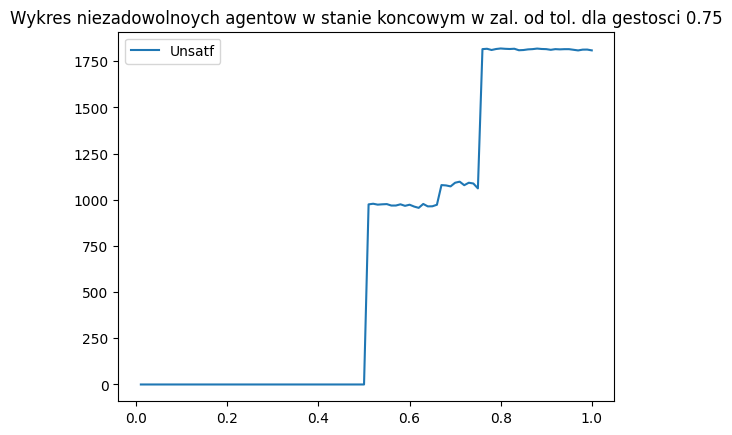

Spodziewany czas to 10 * czas_jednej_symluacji
0
1
2
3
4
5
6
7
8
9
10


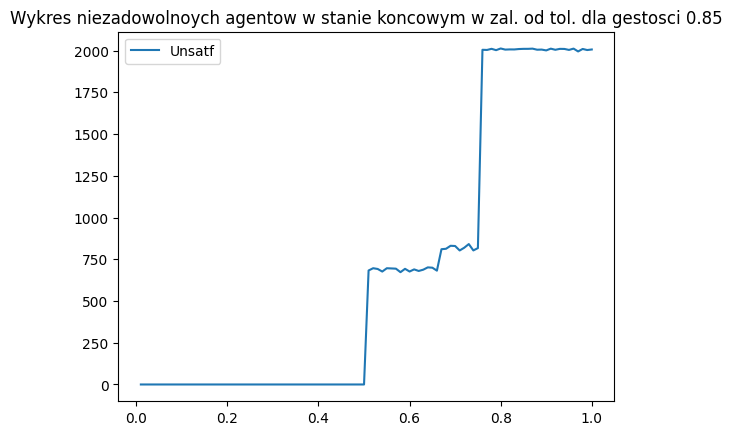

Spodziewany czas to 10 * czas_jednej_symluacji
0
1
2
3
4
5
6
7
8
9
10


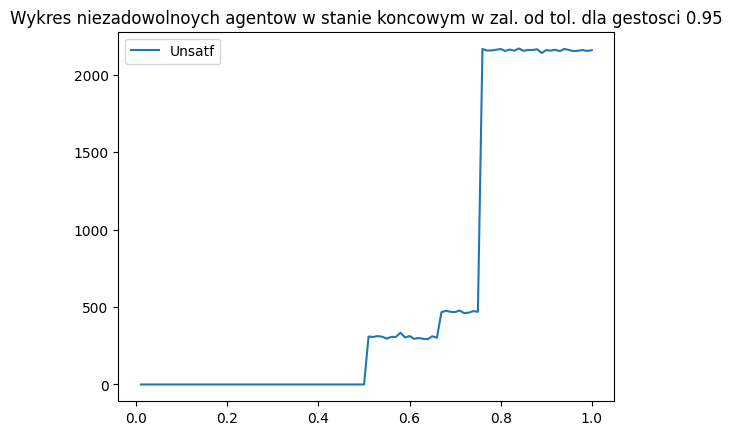

In [18]:
density = 0.75
grid_size = 50
step_size = 0.01
number_average = 10

unsatf, lista_xi = srednia_tolerancji(step_size, density, grid_size, number_average)
mean_unsatf = np.mean(unsatf, axis=0)

plt.plot(lista_xi[0], mean_unsatf, label="Unsatf")
plt.title(f"Wykres niezadowolnoych agentow w stanie koncowym w zal. od tol. dla gestosci {density}")
plt.legend()
plt.show()

density = 0.85

unsatf, lista_xi = srednia_tolerancji(step_size, density, grid_size, number_average)
mean_unsatf = np.mean(unsatf, axis=0)

plt.plot(lista_xi[0], mean_unsatf, label="Unsatf")
plt.title(f"Wykres niezadowolnoych agentow w stanie koncowym w zal. od tol. dla gestosci {density}")
plt.legend()
plt.show()

density = 0.95

unsatf, lista_xi = srednia_tolerancji(step_size, density, grid_size, number_average)
mean_unsatf = np.mean(unsatf, axis=0)

plt.plot(lista_xi[0], mean_unsatf, label="Unsatf")
plt.title(f"Wykres niezadowolnoych agentow w stanie koncowym w zal. od tol. dla gestosci {density}")
plt.legend()
plt.show()

Algorytm ktory laczy dwa elementy jezeli powinny byc w tej samej grupie w naszym przypadku kolorze:
funkcja find sprawdza jaki jest "parent", czyli reprezentat grupy,  funkcja union po prostu scala dwie komorki jezeli nie maja tego samego reprezentanta w zaleznosci od rangi jeden dolaczany jest do drugiego lub na odwrot


In [19]:
class UnionFind:
    def __init__(self, size):
        self.parent = list(range(size))
        self.rank = [0] * size

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx = self.find(x)
        ry = self.find(y)
        if rx != ry:
            if self.rank[rx] < self.rank[ry]:
                self.parent[rx] = ry
            elif self.rank[rx] > self.rank[ry]:
                self.parent[ry] = rx
            else:
                self.parent[ry] = rx
                self.rank[rx] += 1

Algorytm do sprawdzania sasiadow kazdej komorki

In [20]:
def hoshen_kopelman(grid, val):
    # tworzymy siatke wypelniona zerami

    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0

    labels = [[0]*cols for _ in range(rows)]

    #tworzymy ta klase ktora potem wykorzystamy do laczenia grup agentow

    uf = UnionFind(rows * cols + 1)  # +1, by mieć 'bezpieczne' indeksy od 1 w górę
    current_label = 0

    # Pomocnicza funkcja do przekształcania (i, j) w indeks union-find
    def idx(i, j):
        return i * cols + j + 1  # +1 żeby 0 mieć "zarezerwowane" np. dla braku

    # przechodzimy po kazdej komorce i sprawdzamy sasiadow gornego i lewego, jezeli obaj maja 1 to
    for i in range(rows):
        for j in range(cols):

            if grid[i][j] == val:
                up_label = labels[i-1][j] if i > 0 else 0
                left_label = labels[i][j-1] if j > 0 else 0

                if up_label == 0 and left_label == 0:
                    # Nowy klaster
                    current_label += 1
                    labels[i][j] = current_label

                elif up_label != 0 and left_label == 0:
                    labels[i][j] = up_label

                elif up_label == 0 and left_label != 0:
                    labels[i][j] = left_label

                else:
                    # Oba są != 0 to bierzemy mniejszy i scalamy komorki
                    chosen_label = min(up_label, left_label)
                    labels[i][j] = chosen_label
                    uf.union(up_label, left_label)
            else:
                labels[i][j] = 0

    for i in range(rows):
        for j in range(cols):
            if labels[i][j] != 0:
                # reprezentant w union-find
                root_label = uf.find(labels[i][j])
                # Nadpisz w tablicy
                labels[i][j] = root_label

    return labels

Kopelman dla 2 grup

In [21]:
def hoshen_kopelman_2groups(grid):
    labels_plus = hoshen_kopelman(grid, 1)
    labels_minus = hoshen_kopelman(grid, 2)
    return labels_plus, labels_minus

Funkcja wyliczająca

In [23]:
def calculateS(label1, label2):
    cluster_sizes1 = Counter()
    rows1 = len(label1)
    cols1 = len(label1[0]) if rows1 > 0 else 0
    for i in range(rows1):
        for j in range(cols1):
            c1 = label1[i][j]
            if c1 != 0:
                cluster_sizes1[c1] += 1

    cluster_sizes2 = Counter()
    rows2 = len(label2)
    cols2 = len(label2[0]) if rows2 > 0 else 0
    for i in range(rows2):
        for j in range(cols2):
            c2 = label2[i][j]
            if c2 != 0:
                cluster_sizes2[c2] += 1

    N_agents1 = sum(cluster_sizes2.values())
    N_agents2 = sum(cluster_sizes2.values())

    N_tot = N_agents1 + N_agents2

    sum_sq1 = sum((sz * sz) for sz in cluster_sizes1.values())
    sum_sq2 = sum((sz * sz) for sz in cluster_sizes1.values())

    sq_tot = sum_sq1 + sum_sq2

    s_value = 2.0 * sq_tot / (N_tot * N_tot)
    return s_value

Symulacja do wyliczania S

In [24]:
def simulation_of_S(grid_size=20, density=0.95, step_size=0.1):

    s_list = []
    tol_list = []

    for i in range(1, int(1/step_size + 1)):

        print(i*step_size)
        tol_list.append(i*step_size)

        unsatfTEMP, grid = run_schelling_simulation(grid_size=grid_size, density=density, tolerance=i*step_size, plot=False)
        lp, lm = hoshen_kopelman_2groups(grid)
        s_list.append(calculateS(lp, lm))

    return s_list, tol_list

Wyznaczenie S dla różnych gęstości

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.99
1.0


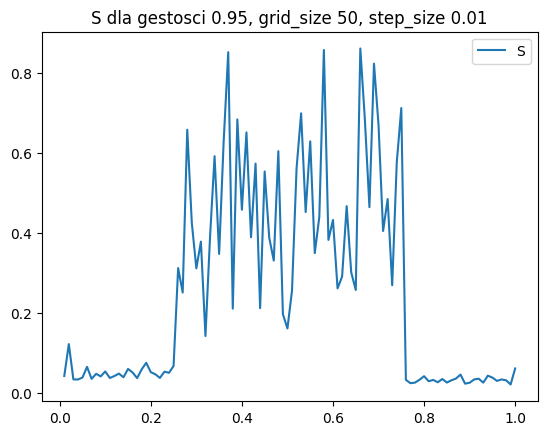

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.99
1.0


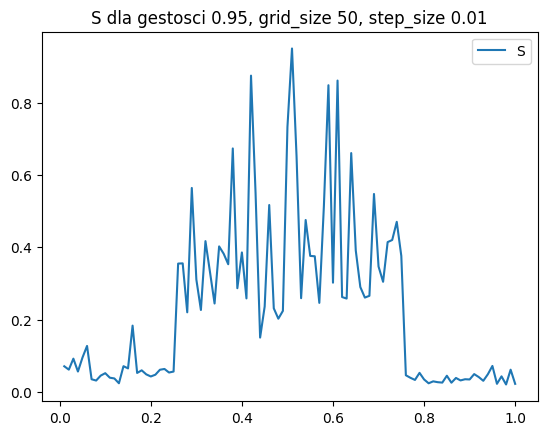

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.99
1.0


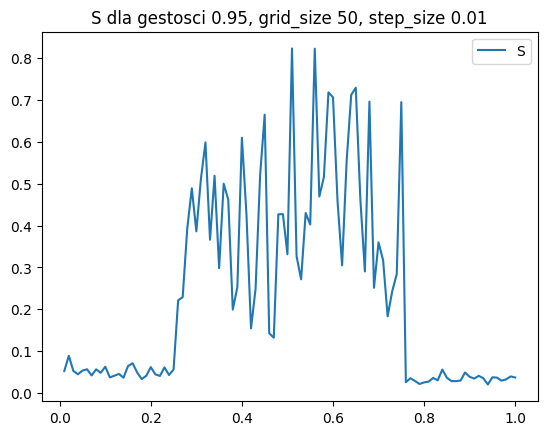

In [25]:
density_s = 0.75
grid_size_s = 40
step_size_s = 0.01

s, tol = simulation_of_S(grid_size=grid_size, density=density, step_size=step_size)
plt.plot(tol, s, label="S")
plt.legend()
plt.title(f'S dla gestosci {density}, grid_size {grid_size}, step_size {step_size}')
plt.show()

density_s = 0.85

s, tol = simulation_of_S(grid_size=grid_size, density=density, step_size=step_size)
plt.plot(tol, s, label="S")
plt.legend()
plt.title(f'S dla gestosci {density}, grid_size {grid_size}, step_size {step_size}')
plt.show()

density_s = 0.95

s, tol = simulation_of_S(grid_size=grid_size, density=density, step_size=step_size)
plt.plot(tol, s, label="S")
plt.legend()
plt.title(f'S dla gestosci {density}, grid_size {grid_size}, step_size {step_size}')
plt.show()